# Notebook 01: Vectorstore Build

## Goal

Chunk all 18 medical textbooks, embed with Qwen3-Embedding-0.6B, and persist a FAISS index to disk.

This notebook runs **once**. After it completes, all RAG queries load the saved index in seconds - no GPU needed.

## Output
```
models/vectorstore/
  - index.faiss     # FAISS IndexFlatIP (exact cosine), 143 MB
  - texts.pkl       # raw chunk strings parallel to index vectors, 97 MB
  - metadata.pkl    # {book, friendly_name, chunk_idx} per chunk, 1 MB
  - config.json     # build settings for reproducibility
```

## Run-time
~45 minutes on Colab T4 GPU (free tier).

## 0. Environment Setup

In [ ]:
import sys
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    if not Path('/content/emma').exists():
        !git clone https://github.com/jaxendutta/emma.git
    os.chdir('/content/emma')
    !pip install -e . -q
    !pip install faiss-cpu sentence-transformers ipywidgets -q
    drive.mount('/content/drive')

import gc
import json
import time
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as ipy_display

from src.data import REPO_ROOT, load_textbook
from src.vectorstore import (
    CHUNK_OVERLAP,
    CHUNK_SIZE,
    VECTORSTORE_DIR,
    build_faiss_index,
    chunk_all_textbooks,
    chunk_text,
    embed_texts,
    load_embedding_model,
    load_index_with_texts,
    save_index_with_texts,
    search,
)

print(f'Environment : {"Google Colab" if IN_COLAB else "Local"}')
print(f'Repo root   : {REPO_ROOT}')
print(f'Chunk size  : {CHUNK_SIZE} words  |  Overlap: {CHUNK_OVERLAP} words')
print(f'Output dir  : {VECTORSTORE_DIR}')

Environment : Local
Repo root   : C:\Projects\emma
Chunk size  : 400 words  |  Overlap: 50 words
Output dir  : C:\Projects\emma\models\vectorstore


In [2]:
# ── Embedding model selector ─────────────────────────────────────────────────
# Reads all embedding models from config/models.json and builds a dropdown.
# The selected model drives Sections 2, 3, and 4.

with open(REPO_ROOT / 'config' / 'models.json', encoding='utf-8') as _f:
    _models_cfg = json.load(_f)

_emb_models = _models_cfg['embeddings_models']

def _model_label(m: dict) -> str:
    rank_str = f"RTEB rank #{m['rteb_healthcare_rank']}" if m.get('rteb_healthcare_rank') else "no RTEB rank"
    default_tag = "  [default]" if m.get('default_embedding') else ""
    return f"{m['name']}  ({m['size']}, {rank_str}){default_tag}"

_options = [(_model_label(m), m['id']) for m in _emb_models]
_default_id = next((m['id'] for m in _emb_models if m.get('default_embedding')), _emb_models[0]['id'])

model_selector = widgets.Dropdown(
    options=_options,
    value=_default_id,
    description='Embedding:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='520px'),
)
model_info_out = widgets.Output()

def _show_model_info(model_id: str) -> None:
    m = next((x for x in _emb_models if x['id'] == model_id), None)
    if not m:
        return
    vs_dir = VECTORSTORE_DIR / model_id
    exists = (vs_dir / 'index.faiss').exists()
    status = f'  Status   : ✓ vectorstore exists at {vs_dir}' if exists else f'  Status   : ○ not yet built → run Section 3'
    print(f"  Model    : {m['name']}")
    print(f"  HF repo  : {m['hf_repo']}")
    rteb = m.get('rteb_healthcare_rank')
    print(f"  RTEB rank: {rteb if rteb else 'n/a'}  |  dim={m['embedding_dim']}")
    print(f"  Provider : {m['provider']}  |  {m['size']}  |  {m['license']}")
    print(status)

def _on_change(change):
    with model_info_out:
        model_info_out.clear_output(wait=True)
        _show_model_info(change['new'])

model_selector.observe(_on_change, names='value')

print('Select an embedding model:')
ipy_display(model_selector, model_info_out)
with model_info_out:
    _show_model_info(model_selector.value)

Select an embedding model:


Dropdown(description='Embedding:', index=1, layout=Layout(width='520px'), options=(('Qwen 3 Embeddings 0.6B  (…

Output()

In [ ]:
# ── GPU / device detection ───────────────────────────────────────────────────
import torch

_device_info = {}

if torch.cuda.is_available():
    _free_gb  = torch.cuda.mem_get_info()[0] / 1024**3
    _total_gb = torch.cuda.mem_get_info()[1] / 1024**3
    _device_info = {'type': 'cuda', 'name': torch.cuda.get_device_name(0),
                    'free_gb': _free_gb, 'total_gb': _total_gb}
    print(f'Device : CUDA — {_device_info["name"]}')
    print(f'VRAM   : {_free_gb:.1f} GB free / {_total_gb:.1f} GB total')
    if _free_gb < 1.5:
        print('⚠︎  Very low VRAM — restart runtime before running the full build')
    elif _free_gb < 4.0:
        print('⚠︎  Moderate VRAM — watch for OOM during embedding; use batch_size=8 if needed')
    else:
        print('✓ Sufficient VRAM for the full build (batch_size=16 is safe)')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    _device_info = {'type': 'mps'}
    print('Device : MPS (Apple Silicon)')
    print('ⓘ  MPS will be used automatically for embedding')
    print('⚠︎  MPS unified memory — use batch_size=8 to avoid pressure on system RAM')
else:
    _device_info = {'type': 'cpu'}
    print('Device : CPU only')
    print('  No GPU detected — embedding will be slow (~8–10× vs a T4)')
    print('    Consider using Google Colab for the full build (Section 3)')
    if not IN_COLAB:
        print('    Or connect a GPU and rerun this cell')

Device : CPU only
⚠️  No GPU detected — embedding will be slow (~8–10× vs a T4)
    Consider using Google Colab for the full build (Section 3)
    Or connect a GPU and rerun this cell


## 1. Chunking preview

Sanity-check word-level chunking before committing to the full build.

In [4]:
# Inspect chunks from Harrison's (largest book)
harrison = load_textbook('InternalMed_Harrison')
chunks = chunk_text(harrison)

print(f'Harrison total chars : {len(harrison):,}')
print(f'Harrison chunk count : {len(chunks):,}')
print(f'\n── Chunk 0 (first {CHUNK_SIZE} words) ──')
print(chunks[0][:400])
print(f'\n── Overlap check: last 10 words of chunk 0 / first 10 of chunk 1 ──')
print('end of 0  :', ' '.join(chunks[0].split()[-10:]))
print('start of 1:', ' '.join(chunks[1].split()[:10]))

[Textbook] Loaded 'Harrison's Internal Medicine'  (22,312,859 chars)
Harrison total chars : 22,312,859
Harrison chunk count : 9,161

── Chunk 0 (first 400 words) ──
xxxviii its related products in new formats. Kim Davis, as Associate Managing We are privileged to have compiled this 19th edition and areEditor, has adeptly ensured that the complex production of this multi-enthusiastic about all that it offers our readers. We learned much in the authored textbook proceeded smoothly and efficiently. Dominik Pucek process of editing Harrison’s and hope that you wi

── Overlap check: last 10 words of chunk 0 / first 10 of chunk 1 ──
end of 0  : the foundation for the solution to many clinical problems. Spectacular
start of 1: that despite more than 60 years of scientific advances since


In [5]:
# Chunk stats across ALL 18 textbooks (no embedding — fast)
texts, metadata = chunk_all_textbooks()

meta_df = pd.DataFrame(metadata)
book_stats = (
    meta_df.groupby('friendly_name')
    .size()
    .reset_index(name='n_chunks')
    .sort_values('n_chunks', ascending=False)
)
print(f'\nTotal chunks across all books: {len(texts):,}')
display(book_stats.style.format({'n_chunks': '{:,}'}))

Chunking textbooks: 100%|██████████| 18/18 [00:01<00:00, 12.24book/s]



[Vectorstore] Total chunks: 36,723 across 18 books

Total chunks across all books: 36,723


,friendly_name,n_chunks
6,Harrison's Internal Medicine,"9,161"
16,Schwartz Surgery,"4,576"
0,Adams Neurology,"3,618"
17,Williams Obstetrics,"2,740"
12,Novak's Gynecology,"2,332"
1,Alberts Cell Biology,"2,157"
8,Katzung Pharmacology,"2,088"
7,Janeway's Immunology,"1,425"
15,Ross Histology,"1,323"
14,Robbins Pathology,"1,296"


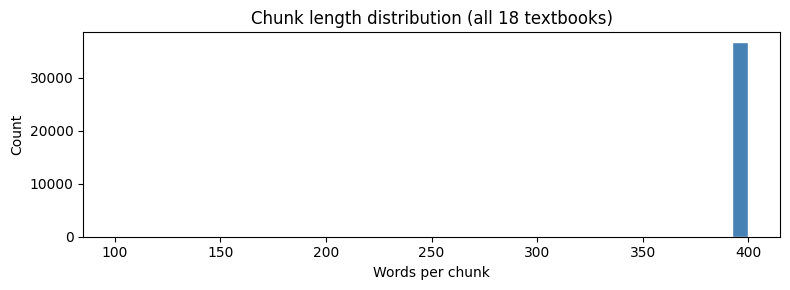

Min: 100  Median: 400  Max: 400


In [6]:
# Chunk length distribution (words)
chunk_lens = [len(t.split()) for t in texts]
plt.figure(figsize=(8, 3))
plt.hist(chunk_lens, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Words per chunk')
plt.ylabel('Count')
plt.title('Chunk length distribution (all 18 textbooks)')
plt.tight_layout()
plt.show()
print(f'Min: {min(chunk_lens)}  Median: {int(np.median(chunk_lens))}  Max: {max(chunk_lens)}')

## 2. Embedding Model Smoke Test

Load the model selected above and verify the similarity matrix makes medical sense.

In [7]:
# Load the selected embedding model
# Downloads ~1.2 GB on first run, then cached by sentence-transformers
_selected_emb = next(m for m in _emb_models if m['id'] == model_selector.value)
print(f'Loading : {_selected_emb["name"]}  ({_selected_emb["hf_repo"]})')

model = load_embedding_model(model_selector.value)
print(f'Embedding dim: {model.get_sentence_embedding_dimension()}')

Loading : Octen Embedding 0.6B  (Octen/Octen-Embedding-0.6B)


No sentence-transformers model found with name sentence-transformers/octen-embedding-0.6b. Creating a new one with mean pooling.


[Vectorstore] Could not load octen-embedding-0.6b: sentence-transformers/octen-embedding-0.6b is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`
[Vectorstore] Falling back to all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dim: 384


In [8]:
# Cosine similarity sanity check
# Expect: septic shock pairs > septic shock vs aspirin > septic shock vs anatomy
sample_texts = [
    'Septic shock is defined by vasopressor requirement and lactate >2 mmol/L despite fluid resuscitation.',
    'Management of septic shock includes early antibiotics, IV fluids, and norepinephrine as first-line vasopressor.',
    'Myocardial infarction results from plaque rupture causing coronary artery occlusion and myocardial necrosis.',
    'Aspirin irreversibly inhibits COX-1 and COX-2, reducing thromboxane A2 synthesis and platelet aggregation.',
    'The brachial plexus is formed from the ventral rami of C5 through T1 nerve roots.',
]
labels = ['Septic shock def', 'Septic shock tx', 'MI', 'Aspirin', 'Brachial plexus']

sample_emb = embed_texts(sample_texts, model, batch_size=5, show_progress=False)
sim = sample_emb @ sample_emb.T

sim_df = pd.DataFrame(sim.round(3), index=labels, columns=labels)
print('Cosine similarity matrix:')
display(sim_df)
print('\n✓ Expect row 0↔1 (septic shock) > row 0↔2 (MI) > row 0↔4 (anatomy)')

Cosine similarity matrix:


,Septic shock def,Septic shock tx,MI,Aspirin,Brachial plexus
Septic shock def,1.000,0.755,0.121,0.076,0.145
Septic shock tx,0.755,1.000,0.093,0.156,0.117
MI,0.121,0.093,1.000,0.259,-0.026
Aspirin,0.076,0.156,0.259,1.000,0.036
Brachial plexus,0.145,0.117,-0.026,0.036,1.000



✓ Expect row 0↔1 (septic shock) > row 0↔2 (MI) > row 0↔4 (anatomy)


## 3. Full build

<div class="alert alert-block alert-danger">
    <div style="padding-bottom: 0px; font-size: 1.25em;">
        <b>⚠ Important</b>
    </div>

<b>Run once per model.</b>
The build cell below checks whether <code style="font-size: 0.9em;">models/vectorstore/&lt;selected-model&gt;/index.faiss</code> already exists and skips automatically.
Set <code style="font-size: 0.9em;">FORCE_REBUILD = True</code> in the build cell if you want to re-embed from scratch.
</div>

<div class="alert alert-block alert-info">
    <div style="padding-bottom: 10px; font-size: 1.2em;">
        <b>💡 Tip</b>
    </div>
    Use a GPU for the embedding step — it is ~8–10× faster than CPU.<br>
    <ul>
        <li><b>Colab</b>: connect to a T4 via <em>Runtime → Change runtime type → GPU</em> (or the VS Code Colab extension).</li>
        <li><b>Local</b>: ensure your CUDA drivers are installed and the GPU cell above shows a device. The embedding code picks up the GPU automatically.</li>
        <li><b>Apple Silicon</b>: MPS is detected automatically; use <code>batch_size=8</code>.</li>
    </ul>
</div>

In [ ]:
# ── Full vectorstore build ───────────────────────────────────────────────────
# Reads the model chosen in the selector above.
# Set FORCE_REBUILD = True to re-embed even if the index already exists.

FORCE_REBUILD = False
batch_size    = 16   # safe for 0.6B models on T4; use 8 for MPS or low VRAM

_selected_id  = model_selector.value
_selected_emb = next(m for m in _emb_models if m['id'] == _selected_id)
index_dir     = VECTORSTORE_DIR / _selected_id
index_path    = index_dir / 'index.faiss'

if index_path.exists() and not FORCE_REBUILD:
    print(f'\u2139 Vectorstore for \u201c{_selected_emb["name"]}\u201d already exists.')
    print(f'  Path : {index_dir}')
    for fname in ['index.faiss', 'texts.pkl', 'metadata.pkl', 'config.json']:
        p = index_dir / fname
        size_str = f'{p.stat().st_size / 1024**2:.1f} MB' if p.exists() else 'MISSING'
        print(f'  {fname:<20s}  {size_str}')
    print('\nSkipping build. Jump to Section 4.')
    print('Set FORCE_REBUILD = True above and re-run this cell to rebuild from scratch.')
else:
    if FORCE_REBUILD and index_path.exists():
        print(f'FORCE_REBUILD=True \u2014 rebuilding over existing index at {index_dir}')

    import shutil
    os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

    t0 = time.time()

    print(f'Building vectorstore for \u201c{_selected_emb["name"]}\u201d')
    print(f'  HF repo : {_selected_emb["hf_repo"]}')
    print(f'  Save to : {index_dir}')
    print()

    print('Step 1/4: Chunking textbooks...')
    _texts, _metadata = chunk_all_textbooks()

    print('Step 2/4: Loading embedding model...')
    _model = load_embedding_model(_selected_id)
    gc.collect()

    print(f'Step 3/4: Embedding {len(_texts):,} chunks (batch_size={batch_size})...')
    _embeddings = embed_texts(_texts, _model, batch_size=batch_size)

    print('Step 4/4: Building FAISS index and saving...')
    _index = build_faiss_index(_embeddings)
    save_index_with_texts(
        index=_index,
        metadata=_metadata,
        texts=_texts,
        save_dir=VECTORSTORE_DIR,
        embedding_model_id=_selected_id,
    )

    elapsed = time.time() - t0
    print(f'\n\u2713 Build complete in {elapsed/60:.1f} min')
    print(f'  {_index.ntotal:,} vectors | dim={_index.d} | {len(_texts):,} chunks')

    if IN_COLAB:
        print('\nCopying to Google Drive...')
        drive_dest = Path(f'/content/drive/MyDrive/emma/models/vectorstore/{_selected_id}')
        drive_dest.mkdir(parents=True, exist_ok=True)
        for f in index_dir.glob('*'):
            shutil.copy(f, drive_dest / f.name)
            print(f'  \u2713 {f.name:<20s} {f.stat().st_size/1024**2:.1f} MB')
        print(f'Google Drive path: {drive_dest}')

Building vectorstore for “Octen Embedding 0.6B”
  HF repo : Octen/Octen-Embedding-0.6B
  Save to : C:\Projects\emma\models\vectorstore\octen-embedding-0.6b

Step 1/4: Chunking textbooks...


Chunking textbooks:  33%|███▎      | 6/18 [00:00<00:00, 22.54book/s]

## 4. Verify: load and query

In [ ]:
# Load index, metadata, texts, and embedding model for the selected model
_selected_id  = model_selector.value
_selected_emb = next(m for m in _emb_models if m['id'] == _selected_id)
_index_dir    = VECTORSTORE_DIR / _selected_id

index, metadata, texts = load_index_with_texts(index_dir=_index_dir)
model = load_embedding_model(_selected_id)

print(f'Index vectors : {index.ntotal:,}')
print(f'Chunk texts   : {len(texts):,}')
print(f'Metadata rows : {len(metadata):,}')
print(f'Model         : {_selected_emb["hf_repo"]}')

In [ ]:
# Query 1: emergency medicine
q = 'What are the clinical features and emergency management of anaphylaxis?'
results = search(q, index, metadata, texts, model, k=5)

print(f'Query: "{q}"\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]  chunk {r['chunk_idx']}")
    print(r['text'][:300])
    print()

Query: "What are the clinical features and emergency management of anaphylaxis?"

Rank 1  score=0.7196  [Harrison's Internal Medicine]  chunk 7007
to beef, lamb, and pork. Individuals differ in the time of appearance of symptoms and signs, butthehallmarkoftheanaphylacticreactionistheonsetofsomemanifestation within seconds to minutes after introduction of the antigen (with the exception of alpha-galactose allergy), generally by injection or les

Rank 2  score=0.7146  [Nelson Pediatrics]  chunk 536
recommendations for avoidance is suggested for patients following severe reactions or anaphylaxis. Skin testing and serum IgEspecific testing are available for foods, inhalants, insect venoms, drugs (penicillin), vaccines, and latex. Educating the patient and family members about the signs and sympt

Rank 3  score=0.6804  [Nelson Pediatrics]  chunk 535
septic shock (see Chapter 40). Avoidance of triggering agents is important in the management of urticaria and angioedema. The mainstay of pharm

In [ ]:
# Query 2: USMLE-style clinical vignette
q = '58-year-old man, crushing chest pain radiating to left arm, diaphoresis, ST elevation in II III aVF. Diagnosis and management?'
results = search(q, index, metadata, texts, model, k=5)

print('Query: inferior STEMI vignette\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]")
    print(r['text'][:300])
    print()

Query: inferior STEMI vignette

Rank 1  score=0.6640  [First Aid Step 2]
CAD (stenosis > 50%) 1 3 5 13 ASA use in past seven days 1 4 7 20 Presentation 5 12 26 Severe angina (≥ 2 episodes within 24 hours) 1 6/7 19 41 ST deviation ≥ 0.5 mm 1 + cardiac marker 1 Risk score—total points (0–7) Higher-risk patients (risk score ≥ 3) beneft more from enoxaparin (vs. unfractionat

Rank 2  score=0.6630  [Harrison's Internal Medicine]
to 20% of patients by 5 years. Patients with PVA who develop serious arrhythmias during spontaneous episodes of pain are at a higher risk for sudden cardiac death. In most patients who survive an infarction or the initial 3to 6-month period of frequent episodes, there is a tendency for symptoms and 

Rank 3  score=0.6425  [Harrison's Internal Medicine]
electrocardiograms (ECGs) in this atlas supplement those illustrated in Chap. 268. The interpretations emphasize findings of specific teaching value. All of the figures are from ECG Wave-Maven, Copyright 2003, Beth Is

In [ ]:
# Query 3: pharmacology
q = 'mechanism of action of beta blockers in heart failure and their side effects'
results = search(q, index, metadata, texts, model, k=5)

print(f'Query: "{q}"\n')
for r in results:
    print(f"Rank {r['rank']}  score={r['score']:.4f}  [{r['friendly_name']}]")
    print(r['text'][:300])
    print()

Query: "mechanism of action of beta blockers in heart failure and their side effects"

Rank 1  score=0.7243  [Harrison's Internal Medicine]
by which beta blockers lower blood pressure include a central nervous system effect and inhibition of renin release. Beta blockers are particularly effective in hypertensive patients with tachycardia, and their hypotensive potency is enhanced by coadministration with a diuretic. In lower doses, some

Rank 2  score=0.7194  [Katzung Pharmacology]
winter. CNS effects include mild sedation, vivid dreams, and rarely, depression. Discontinuing the use of β blockers in any patient who develops psychiatric depression should be seriously considered if clinically feasible. It has been claimed that β-receptor antagonist drugs with low lipid solubilit

Rank 3  score=0.7150  [Novak's Gynecology]
profound diuresis may occur and lead to renal impairment. Concurrent use of nonsteroidal anti-inﬂammatory drugs (NSAIDs) limits the effectiveness of this class of drugs

## 5. Book coverage analysis

For a diverse set of queries, which books does retrieval pull from? Good retrieval should draw from domain-appropriate sources.

In [ ]:
# Coverage across 8 medical domains
test_queries = {
    'Sepsis':       'Septic shock pathophysiology and vasopressor management',
    'Cardiology':   'STEMI diagnosis ECG changes and reperfusion therapy',
    'Pharmacology': 'ACE inhibitor mechanism hypertension and renal protection',
    'Neurology':    'Ischaemic stroke tPA eligibility and contraindications',
    'Paediatrics':  'Febrile seizures in children evaluation and management',
    'Immunology':   'T cell receptor signalling and co-stimulatory pathways',
    'Surgery':      'Appendicitis diagnosis laparoscopic vs open appendicectomy',
    'Psychiatry':   'Major depressive disorder DSM-5 diagnostic criteria and treatment',
}

rows = []
for topic, q in test_queries.items():
    for r in search(q, index, metadata, texts, model, k=5):
        rows.append({'topic': topic, 'book': r['friendly_name'], 'score': r['score']})

cov_df = pd.DataFrame(rows)
pivot = cov_df.groupby(['topic', 'book']).size().unstack(fill_value=0)
print('Hits per book per query (top-5 results each):')
display(pivot.to_string())

Hits per book per query (top-5 results each):


"book          Adams Neurology  DSM-5 Psychiatry  First Aid Step 2  Harrison's Internal Medicine  Janeway's Immunology  Katzung Pharmacology  Nelson Pediatrics  Robbins Pathology  Schwartz Surgery\ntopic                                                                                                                                                                                              \nCardiology                  0                 0                 0                             5                     0                     0                  0                  0                 0\nImmunology                  0                 0                 0                             0                     5                     0                  0                  0                 0\nNeurology                   1                 0                 1                             2                     0                     0                  0                  0                 1\nPaediatrics   

## 6. Summary

In [ ]:
_selected_id  = model_selector.value
_selected_emb = next(m for m in _emb_models if m['id'] == _selected_id)
_index_dir    = VECTORSTORE_DIR / _selected_id

config = json.loads((_index_dir / 'config.json').read_text())

meta_df = pd.DataFrame(metadata)
book_chunk_counts = meta_df.groupby('friendly_name').size()
top_book   = book_chunk_counts.idxmax()
top_book_n = int(book_chunk_counts.max())

summary_df = pd.DataFrame([
    {'Item': 'Total chunks',       'Value': f"{index.ntotal:,}"},
    {'Item': 'Number of textbooks','Value': str(config['num_books'])},
    {'Item': 'Embedding model',    'Value': config['model_name']},
    {'Item': 'Embedding dim',      'Value': str(config['embedding_dim'])},
    {'Item': 'Chunk size',         'Value': f"{config['chunk_size']} words"},
    {'Item': 'Overlap',            'Value': f"{config['chunk_overlap']} words"},
    {'Item': 'FAISS index type',   'Value': 'IndexFlatIP (exact cosine)'},
    {'Item': 'Largest book',       'Value': f"{top_book}  ({top_book_n:,} chunks)"},
    {'Item': 'index.faiss size',   'Value': f"{(_index_dir / 'index.faiss').stat().st_size / 1024**2:.1f} MB"},
    {'Item': 'texts.pkl size',     'Value': f"{(_index_dir / 'texts.pkl').stat().st_size / 1024**2:.1f} MB"},
])

display(summary_df)

,Item,Value
0,Total chunks,"36,723"
1,Number of textbooks,18
2,Embedding model,Qwen/Qwen3-Embedding-0.6B
3,Embedding dim,1024
4,Chunk size,400 words
5,Overlap,50 words
6,FAISS index type,IndexFlatIP (exact cosine)
7,Largest book,"Harrison's Internal Medicine (9,161 chunks)"
8,index.faiss size,143.4 MB
9,texts.pkl size,97.3 MB


<div class="alert alert-block alert-warning">
    <div style="padding-bottom: 10px; font-size: 1.2em;">
        <b>⚠ Important</b>
    </div>
If you used Google Colab, the vectorstore files have been generated and saved to your Google Drive.
Navigate to <code style="font-size: 0.9em;">My Drive > emma > models > vectorstore/</code> to download them to your working environment, if you're going to work locally going forward.

<b>Be mindful of where your generated files are!</b> Download them to your local environment if needed. Upload them to your Google Drive if you're working in Colab.
</div>


<div class="alert alert-block alert-info">
Next > Notebook 02: Classification
</div>